<a href="https://colab.research.google.com/github/LielUziahu/MDPI_S_Pistillata_Bet-Hedging/blob/main/Planulae_Volume_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Block 1: Setup & Load 2026 Data
This block  all required libraries and loads 2026 dataset, stripping any hidden spaces from the columns.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sys
import matplotlib
import scipy


# --- GLOBAL PLOT STYLING ---
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,          # Global text size
    "axes.titlesize": 16,     # Plot titles
    "axes.titleweight": "bold", # Global title fontweight
    "axes.titlepad": 25,      # Global title padding
    "axes.labelsize": 14,     # Axis labels
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2
})

# --- GLOBAL COLOR PALETTE & PLOT ARTIFACTS ---
variant_colors = {'HF': '#2ca02c', 'NF': '#d62728'}


global_fig_size = (6, 6) # Reduced width for a slimmer plot
global_jitter = 0.1
global_marker_size = 5
global_alpha = 0.6
global_box_width = 0.4 # New global setting for boxplot width
# Centralized Asterisk Settings
global_asterisk_size = 18
global_asterisk_weight = 'bold'

# Added for cleaner look
global_y_nbins = 3

print("Global styling (with bold asterisks and reduced Y-ticks) initialized.")

# 1. Load 2026 Data
file_2026 = 'Planulae size 2026.csv'
df26 = pd.read_csv(file_2026, encoding='latin-1')
df26.columns = df26.columns.str.strip()



Global styling (with bold asterisks and reduced Y-ticks) initialized.


# Block 2: Geometric Filtering
Recalculate the dimensions from your ImageJ Area and Perimeter outputs to filter out any planulae that were imaged horizontally (Aspect Ratio < 2.5).

In [46]:
# 2. Geometric Filtering (Aspect Ratio >= 2.5)
A = df26['area µm²']
P = df26['perimeter µm']
r = (P - np.sqrt(P**2 - 4 * np.pi * A)) / (2 * np.pi)
w = 2 * r
L_total = ((P - 2 * np.pi * r) / 2) + (2 * r)
df26['Aspect_Ratio'] = L_total / w

# Split data into removed vs good
df26_removed_ratio = df26[df26['Aspect_Ratio'] < 2.5]
df26_good = df26[df26['Aspect_Ratio'] >= 2.5].copy()

#Block 3: Remove 1.5 IQR Outliers
This sweeps the dataset to find any extreme volume measurements per morphotype (HF vs. NF).

In [47]:
# 3. Remove 1.5 IQR outliers per group
def remove_outliers(df, group_col, val_col):
    outliers_list = []
    clean_data_list = []

    for name, group in df.groupby(group_col):
        Q1 = group[val_col].quantile(0.25)
        Q3 = group[val_col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter rows
        outliers = group[(group[val_col] < lower_bound) | (group[val_col] > upper_bound)]
        clean = group[(group[val_col] >= lower_bound) & (group[val_col] <= upper_bound)]

        outliers_list.append(outliers)
        clean_data_list.append(clean)

    return pd.concat(clean_data_list), pd.concat(outliers_list)

# Apply filter specifically to Volume
df26_clean, df26_outliers = remove_outliers(df26_good, 'morph', 'Volume mm³')

#Block 4: Data Removal Report
Prints a transparent log of exactly what data was removed and why

In [48]:
# 4. Print Data Removal Report
print("--- 2026 DATA REMOVAL REPORT ---")
print(f"Total larvae ignored due to Aspect Ratio < 2.5: {len(df26_removed_ratio)}")
if not df26_removed_ratio.empty:
    print(df26_removed_ratio[['no', 'morph', 'Label', 'Aspect_Ratio']])
print("-" * 40)

print(f"Total outliers removed (1.5 IQR): {len(df26_outliers)}")
if not df26_outliers.empty:
    print(df26_outliers[['no', 'morph', 'Label', 'Volume mm³']])
print("-" * 40)
print(f"Total larvae remaining for analysis: {len(df26_clean)}")

--- 2026 DATA REMOVAL REPORT ---
Total larvae ignored due to Aspect Ratio < 2.5: 4
      no morph  Label  Aspect_Ratio
50    51    HF      1      1.783012
81    82    HF     11      2.254283
94    95    NF      2      2.248411
101  102    NF      4      1.653646
----------------------------------------
Total outliers removed (1.5 IQR): 9
      no morph  Label  Volume mm³
5      6    HF      2      0.4590
8      9    HF      1      0.4795
12    13    HF      2      0.4758
14    15    HF      2      0.4609
16    17    HF      2      0.1601
24    25    HF      3      0.1490
48    49    HF      5      0.5298
54    55    HF      5      0.4530
109  110    NF      2      0.4689
----------------------------------------
Total larvae remaining for analysis: 125


# Block 5: Normality Test
Evaluates if the volume distribution of HF and NF cohorts follow a normal Gaussian curve using the Shapiro-Wilk test.


--- 2026 NORMALITY TEST (Cleaned Data) ---
Morph: HF (n=82) | Shapiro-Wilk p-value: 0.96090 | Normal ✅
Morph: NF (n=43) | Shapiro-Wilk p-value: 0.66581 | Normal ✅


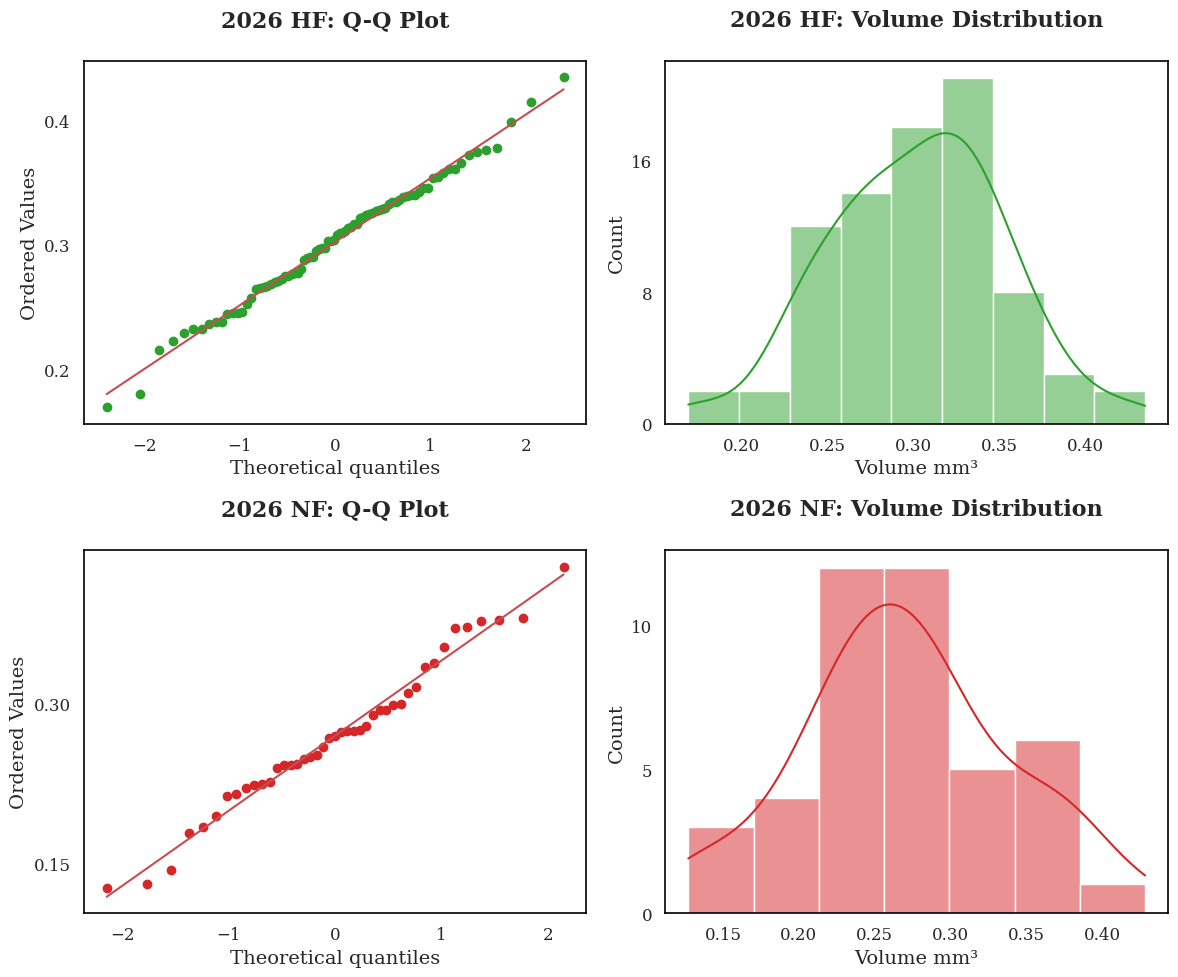

In [49]:
# 5. Normality Test & Diagnostic Plots
import matplotlib.ticker as ticker

unique_morphs = df26_clean['morph'].unique()
print("\n--- 2026 NORMALITY TEST (Cleaned Data) ---")
normality_results = {}

# Create a figure for Q-Q plots to support the statistical test
fig_qq = plt.figure(figsize=(12, 5 * len(unique_morphs)))

for i, morph in enumerate(unique_morphs):
    data = df26_clean[df26_clean['morph'] == morph]['Volume mm³'].dropna()

    # Statistical Test
    shapiro_p = stats.shapiro(data)[1]
    is_normal = shapiro_p > 0.05
    normality_results[morph] = is_normal

    result = "Normal ✅" if is_normal else "NOT Normal ❌"
    print(f"Morph: {morph} (n={len(data)}) | Shapiro-Wilk p-value: {shapiro_p:.5f} | {result}")

    # Diagnostic Plotting (Q-Q Plots)
    ax_qq = plt.subplot(len(unique_morphs), 2, 2*i + 1)
    stats.probplot(data, dist="norm", plot=ax_qq)
    ax_qq.get_lines()[0].set_color(variant_colors.get(morph, 'black'))
    ax_qq.set_title(f'2026 {morph}: Q-Q Plot')
    ax_qq.yaxis.set_major_locator(ticker.MaxNLocator(nbins=global_y_nbins))

    # Histogram for visual check
    ax_hist = plt.subplot(len(unique_morphs), 2, 2*i + 2)
    sns.histplot(data, kde=True, ax=ax_hist, color=variant_colors.get(morph, 'skyblue'))
    ax_hist.set_title(f'2026 {morph}: Volume Distribution')
    ax_hist.yaxis.set_major_locator(ticker.MaxNLocator(nbins=global_y_nbins))

plt.tight_layout()
plt.show()

# Block 6 & 7: Automated Statistical Decision & Summary
Automatically reads the output of Block 5. If both groups are normal, it runs a T-test; if either group is skewed, it defaults to the non-parametric Mann-Whitney U test.

In [50]:
# 6. Statistical test based on normality & 7. Full statistical summary
print("\n--- STATISTICAL COMPARISON SUMMARY ---")
morphs = list(normality_results.keys())

if len(morphs) == 2:
    group1 = df26_clean[df26_clean['morph'] == morphs[0]]['Volume mm³'].dropna()
    group2 = df26_clean[df26_clean['morph'] == morphs[1]]['Volume mm³'].dropna()

    # Logic gate for stats
    if all(normality_results.values()):
        print("Verdict: Both groups are normally distributed.")
        stat, p_val = stats.ttest_ind(group1, group2)
        test_used = "Independent T-test"
    else:
        print("Verdict: Non-normal distribution detected.")
        stat, p_val = stats.mannwhitneyu(group1, group2)
        test_used = "Mann-Whitney U"

    significance = "Significant ⭐" if p_val < 0.05 else "Not Significant (NS)"

    # 7. Summary
    print(f"\nComparison: {morphs[0]} vs {morphs[1]}")
    print(f"Test Used: {test_used}")
    print(f"Statistic: {stat:.5f}")
    print(f"p-value: {p_val:.5e} | {significance}")
else:
    print("More than 2 morphs detected. Code requires adjustment for ANOVA/Kruskal-Wallis.")


--- STATISTICAL COMPARISON SUMMARY ---
Verdict: Both groups are normally distributed.

Comparison: HF vs NF
Test Used: Independent T-test
Statistic: 3.00522
p-value: 3.21720e-03 | Significant ⭐


# Block 8: Global Style Plotting
Creates a publication-ready figure featuring the Q-Q distribution plots from your notebook alongside a final Boxplot with jittered dots to show the exact spread of your HF vs. NF volume.

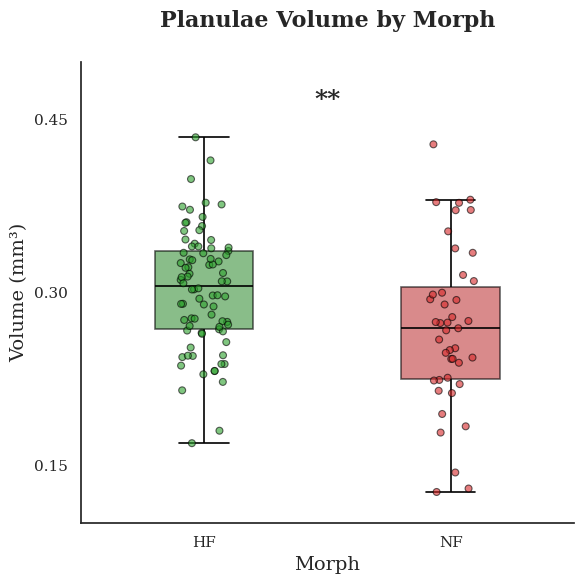

In [62]:
# 8. Final Comparison Plot
import matplotlib.ticker as ticker

# Force global styling parameters from Block 1
plt.rcParams.update({
    "font.family": "Serif",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.titleweight": "bold",
    "axes.titlepad": 25,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "axes.edgecolor": "black",
    "axes.linewidth": 1.2
})
sns.set_theme(style="white", font="serif")

fig, ax_box = plt.subplots(figsize=global_fig_size)

plot_order = [m for m in ['HF', 'NF'] if m in df26_clean['morph'].unique()]

# Main comparison plot
sns.boxplot(
    data=df26_clean,
    x='morph',
    y='Volume mm\u00b3',
    order=plot_order,
    hue='morph',
    palette=variant_colors,
    ax=ax_box,
    showfliers=False,
    legend=False,
    width=global_box_width,
    boxprops=dict(edgecolor="black", linewidth=1.2, alpha=0.6),
    whiskerprops=dict(color="black", linewidth=1.2),
    capprops=dict(color="black", linewidth=1.2),
    medianprops=dict(color="black", linewidth=1.2)
)

# Jittered points
sns.stripplot(
    data=df26_clean,
    x='morph',
    y='Volume mm\u00b3',
    order=plot_order,
    hue='morph',
    palette=variant_colors,
    alpha=global_alpha,
    jitter=global_jitter,
    size=global_marker_size,
    ax=ax_box,
    legend=False,
    linewidth=0.8,
    edgecolor='black'
)

# --- SIGNIFICANCE ANNOTATION (Rules: * <= 0.05, ** <= 0.01, *** <= 0.001) ---
if 'p_val' in globals():
    if p_val <= 0.001:
        sig_str = "***"
    elif p_val <= 0.01:
        sig_str = "**"
    elif p_val <= 0.05:
        sig_str = "*"
    else:
        sig_str = ""

    if sig_str:
        x1, x2 = 0, 1
        y_max = df26_clean['Volume mm\u00b3'].max()
        # Adjust height slightly for visibility without the line
        h_ast = y_max * 1.05

        # Place tiered asterisk at center without the bracket line
        ax_box.text((x1+x2)*.5, h_ast, sig_str,
                    ha='center', va='bottom',
                    fontsize=global_asterisk_size,
                    fontweight=global_asterisk_weight)

# Labels and Ticks
ax_box.set_title("Planulae Volume by Morph", fontsize=16, fontweight=global_asterisk_weight, pad=25)
ax_box.set_ylabel("Volume (mm\u00b3)", fontsize=14)
ax_box.set_xlabel("Morph", fontsize=14)
ax_box.set_ylim(0.1, 0.5) # Set Y-axis up to 0.5
ax_box.yaxis.set_major_locator(ticker.MaxNLocator(nbins=global_y_nbins))

sns.despine()
plt.tight_layout()
plt.show()

In [64]:
import pandas as pd

# 10. Statistical Summary Table for Report
summary_data = []

for morph in morphs:
    group_data = df26_clean[df26_clean['morph'] == morph]['Volume mm³']
    summary_data.append({
        'Morphotype': morph,
        'n': len(group_data),
        'Mean Volume (mm³)': f"{group_data.mean():.4f}",
        'Std Dev': f"{group_data.std():.4f}",
        'Normality (p > 0.05)': "Pass" if normality_results[morph] else "Fail"
    })

# Create DataFrame
stats_table = pd.DataFrame(summary_data)

# Add Test Details
print("--- 2026 STATISTICAL SUMMARY TABLE ---")
display(stats_table)

print(f"\nTest Used: {test_used}")
print(f"p-value: {p_val:.5e}")
print(f"Significance: {sig_str if sig_str else 'NS'}")

--- 2026 STATISTICAL SUMMARY TABLE ---


,Morphotype,n,Mean Volume (mm³),Std Dev,Normality (p > 0.05)
0,HF,82,0.3024,0.0505,Pass
1,NF,43,0.2698,0.0691,Pass



Test Used: Independent T-test
p-value: 3.21720e-03
Significance: **


In [69]:
# Save the figure in 600 DPI PNG and TIFF formats
# Note: Using pil engine for TIFF to handle compression correctly

# Save PNG
fig.savefig('Planulae_Volume_Comparison_2026.png', dpi=600, bbox_inches='tight')

# Save TIFF using PIL to support LZW compression
fig.savefig('Planulae_Volume_Comparison_2026.tiff', dpi=600, bbox_inches='tight')

print("Figures saved successfully:")
print("- Planulae_Volume_Comparison_2026.png")
print("- Planulae_Volume_Comparison_2026.tiff")

Figures saved successfully:
- Planulae_Volume_Comparison_2026.png
- Planulae_Volume_Comparison_2026.tiff


# Block 9: Library Versions

In [52]:
# 9. Summary of all libraries and version used
print("\n--- LIBRARIES & VERSIONS ---")
print(f"Python version: {sys.version.split(' ')[0]}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"SciPy version: {scipy.__version__}")


--- LIBRARIES & VERSIONS ---
Python version: 3.12.13
Pandas version: 2.2.2
NumPy version: 2.0.2
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
SciPy version: 1.16.3
